# Entrenamiento y Optimización de Modelos: Tutor Diagnóstico CENEVAL
Este notebook documenta el proceso completo de Machine Learning para predecir la probabilidad de éxito de estudiantes en el examen diagnóstico. 

**Fases del proceso:**
1. Generación de conjunto de datos sintético.
2. Análisis Exploratorio de Datos (EDA).
3. Preprocesamiento (Escalado).
4. Entrenamiento de 3 arquitecturas con `GridSearchCV`.
5. Evaluación y serialización del modelo ganador.
6. 
    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Configuración visual
sns.set_theme(style="whitegrid")

## 1. Generación del Conjunto de Datos
Simularemos el comportamiento de 5,000 alumnos considerando sus calificaciones por área, métricas de comportamiento (tiempo, dudas) y semestre actual.

In [ ]:
np.random.seed(42)
n = 5000

# Características
c_soft = np.random.normal(70, 15, n).clip(0, 100)
c_redes = np.random.normal(65, 18, n).clip(0, 100)
c_bd = np.random.normal(75, 12, n).clip(0, 100)
c_mates = np.random.normal(60, 20, n).clip(0, 100)
c_logica = np.random.normal(68, 15, n).clip(0, 100)
tiempo_promedio = np.random.normal(60, 20, n).clip(10, 120)
omitidas = np.random.poisson(2, n).clip(0, 20)
cambios = np.random.poisson(3, n).clip(0, 10)
racha = np.random.normal(5, 3, n).clip(0, 30)
semestre = np.random.randint(6, 10, n)

# Lógica del Target
score_oculto = ((c_soft * 0.25) + (c_bd * 0.20) + (c_mates * 0.20) + (c_logica * 0.20) + (c_redes * 0.15) 
                - (omitidas * 2) - (cambios * 0.5) + (racha * 1.5) + (semestre * 2))
score_final = score_oculto + np.random.normal(0, 8, n)

# 1 = Aprobado, 0 = Reprobado
paso_ceneval = np.where(score_final >= 80, 1, 0)

df = pd.DataFrame({
    'calif_software': c_soft, 'calif_redes': c_redes, 'calif_bd': c_bd,
    'calif_matematicas': c_mates, 'calif_logica': c_logica,
    'tiempo_promedio': tiempo_promedio, 'preguntas_omitidas': omitidas,
    'cambios_respuesta': cambios, 'racha_aciertos': racha, 'semestre_actual': semestre,
    'paso_ceneval': paso_ceneval
})

print(f"Dataset generado con {df.shape[0]} registros y {df.shape[1]} columnas.")
df.head()

Dataset generado con 5000 registros y 11 columnas.


,calif_software,calif_redes,calif_bd,calif_matematicas,calif_logica,tiempo_promedio,preguntas_omitidas,cambios_respuesta,racha_aciertos,semestre_actual,paso_ceneval
0,77.450712,57.372326,66.858063,57.131536,73.224294,63.417471,3,2,4.965200,8,0
1,67.926035,56.838546,71.334006,59.346882,72.249854,60.245109,1,0,5.522139,7,1
2,79.715328,32.678423,67.831427,61.285898,53.952202,51.376899,3,3,1.960391,8,0
3,92.845448,59.058377,76.325017,78.937229,76.693763,59.949467,0,2,0.145810,7,1
4,66.487699,78.190923,89.366142,45.055654,45.648760,69.816833,2,2,1.646426,6,0


## 2. Análisis Exploratorio de Datos (EDA)
Revisaremos la distribución de nuestras clases para asegurar que no haya un desbalance extremo, y analizaremos la correlación entre las características.

C:\Users\mario\AppData\Local\Temp\ipykernel_496\2224492567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='paso_ceneval', palette='viridis')


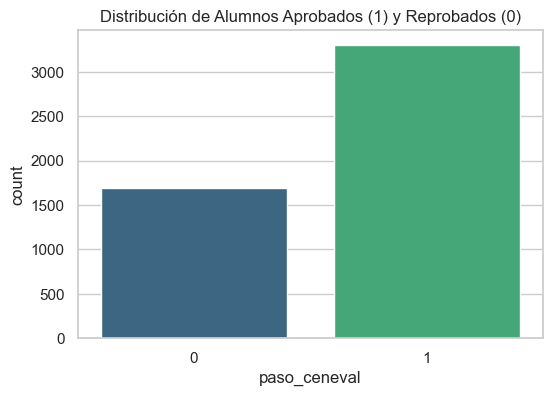

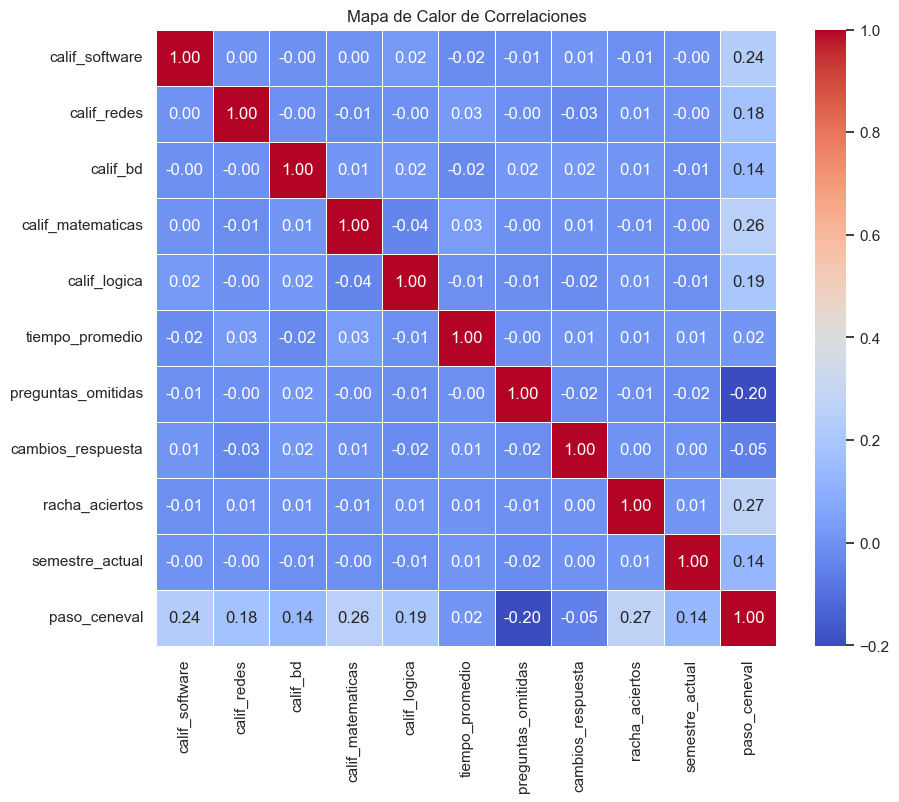

In [ ]:
# 1. Distribución de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='paso_ceneval', palette='viridis')
plt.title('Distribución de Alumnos Aprobados (1) y Reprobados (0)')
plt.show()

# 2. Matriz de Correlación
plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

## 3. Preprocesamiento de Datos
Separamos las características (X) del objetivo (y). Utilizamos `StandardScaler` para normalizar los datos, paso crucial para algoritmos basados en gradiente y distancias.

In [ ]:
X = df.drop('paso_ceneval', axis=1)
y = df['paso_ceneval']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Set de entrenamiento: {X_train.shape[0]} alumnos.")
print(f"Set de prueba: {X_test.shape[0]} alumnos.")

Set de entrenamiento: 4000 alumnos.
Set de prueba: 1000 alumnos.


## 4. Entrenamiento de Modelos con GridSearchCV
Para evitar el sobreajuste y encontrar la mejor combinación de hiperparámetros, realizaremos una búsqueda exhaustiva (GridSearch) con validación cruzada para 3 modelos distintos.

In [ ]:
# Métrica para optimizar
scoring_metric = 'recall' 

print("--- Optimizando Regresión Logística ---")
param_grid_lr = {'C': [0.1, 1, 10], 'max_iter': [1000]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=3, scoring=scoring_metric, n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)
print(f"Mejores parámetros LR: {grid_lr.best_params_}")

print("\n--- Optimizando Random Forest ---")
param_grid_rf = {'n_estimators': [100, 300], 'max_depth': [10, 15, None]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring=scoring_metric, n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
print(f"Mejores parámetros RF: {grid_rf.best_params_}")

print("\n--- Optimizando XGBoost ---")
param_grid_xgb = {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 6]}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, cv=3, scoring=scoring_metric, n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)
print(f"Mejores parámetros XGB: {grid_xgb.best_params_}")

--- Optimizando Regresión Logística ---
Mejores parámetros LR: {'C': 0.1, 'max_iter': 1000}

--- Optimizando Random Forest ---
Mejores parámetros RF: {'max_depth': 10, 'n_estimators': 100}

--- Optimizando XGBoost ---
Mejores parámetros XGB: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


## 5. Evaluación y Serialización
Compararemos el rendimiento de los tres mejores estimadores encontrados por `GridSearchCV` contra el set de pruebas que el modelo nunca ha visto.

In [ ]:
modelos_optimizados = {
    "Regresión Logística": grid_lr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

mejor_modelo_nombre = ""
mejor_recall = 0
modelo_ganador = None

for nombre, modelo in modelos_optimizados.items():
    print(f"\nReporte para: {nombre}")
    predicciones = modelo.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, predicciones)
    rec = recall_score(y_test, predicciones)
    
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Recall   : {rec * 100:.2f}%")
    
    if rec > mejor_recall:
        mejor_recall = rec
        mejor_modelo_nombre = nombre
        modelo_ganador = modelo

print(f"\n el mejor modelo es  {mejor_modelo_nombre} con un Recall de {mejor_recall * 100:.2f}%")

# Serialización
os.makedirs('../models', exist_ok=True)
joblib.dump(modelo_ganador, '../models/modelo_ganador_v2.pkl')
joblib.dump(scaler, '../models/scaler_v2.pkl')



Reporte para: Regresión Logística
Accuracy : 80.80%
Recall   : 86.40%

Reporte para: Random Forest
Accuracy : 78.90%
Recall   : 89.39%

Reporte para: XGBoost
Accuracy : 78.20%
Recall   : 87.59%

 el mejor modelo es  Random Forest con un Recall de 89.39%


['../models/scaler_v2.pkl']